## Домашнее задание 4

- Считайте датасет из файла [loan_prediction_dataset.csv](https://disk.yandex.ru/d/v0Bvg92P5AycBw) — **1 балл**

- Выведите основную информацию о датасете (`info()`, `describe()`) — **2 балла**

- Выведите таблицу пропусков по каждому столбцу:
  - абсолютное число
  - процент пропусков  
  — **3 балла**

- Постройте визуализации пропусков:
  - матрицу пропусков
  - тепловую карту пропусков  
  — **3 балла**

- Проинтерпретируйте полученные графики — **2 балла**

- Разделите признаки с пропусками на:
  - числовые
  - категориальные  
  — **2 балла**

- Заполните пропуски (обоснуйте выбор метода для каждого типа признаков) — **4 балла**

- Проверьте, что пропуски заполнены корректно — **1 балл**

- Покажите статистики до/после заполнения и кратко прокомментируйте изменения — **2 балла**

---

Для сдачи домашней работы запушьте файлы в ветку **hw_4** в вашем репозитории, создайте pull-request и отправьте на ревью @lyutovad 

Считайте датасет из файла loan_prediction_dataset.csv — 1 балл

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

#чтение датасета
df = pd.read_csv('loan_prediction_dataset.csv')

Выведите основную информацию о датасете (info(), describe()) — 2 балла

In [2]:
#основная информация о датасете
print("общая информация")
df.info() 

print("описательные статистики")
#показываем статистики и для чисел и для строк
print(df.describe(include='all'))

общая информация
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB
описательные статистики
         Loan_ID Gender Married Dependents Education Self_Employed  \
c

Выведите таблицу пропусков по каждому столбцу:

абсолютное число
процент пропусков
— 3 балла

In [3]:
#таблица пропусков
print("таблица пропусков по столбцам")
abs_missing = df.isnull().sum()
perc_missing = (df.isnull().sum() / len(df)) * 100

missing_table = pd.DataFrame({
    'абсолютное число': abs_missing,
    'процент пропусков (%)': perc_missing
})
#выводим только те столбцы, где реально есть пропуски
print(missing_table[missing_table['абсолютное число'] > 0])

таблица пропусков по столбцам
                  абсолютное число  процент пропусков (%)
Gender                          13               2.117264
Married                          3               0.488599
Dependents                      15               2.442997
Self_Employed                   32               5.211726
LoanAmount                      22               3.583062
Loan_Amount_Term                14               2.280130
Credit_History                  50               8.143322


Постройте визуализации пропусков:

матрицу пропусков
тепловую карту пропусков
— 3 балла

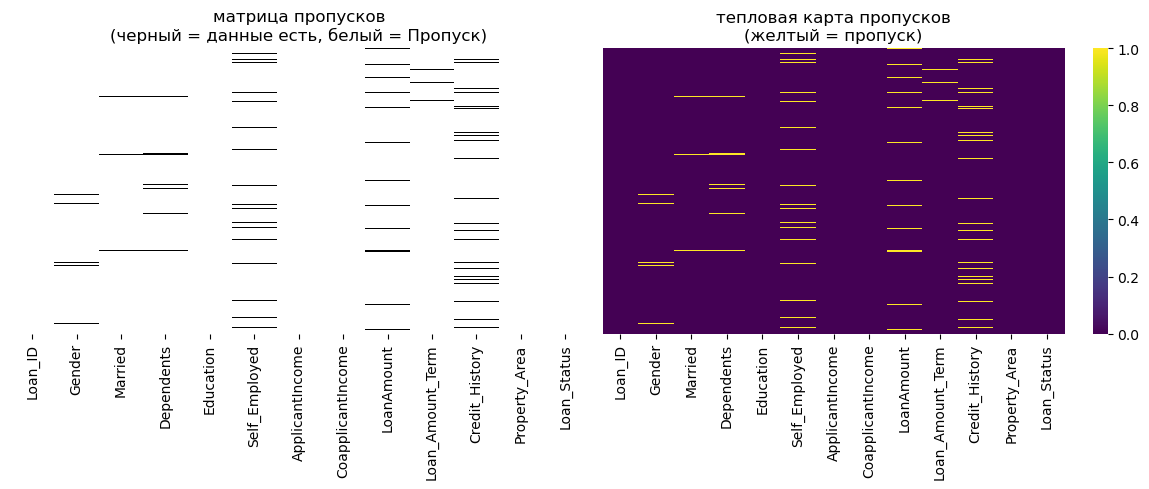

In [4]:
#визуализация пропусков
plt.figure(figsize=(12, 5))

#матрица пропусков
plt.subplot(1, 2, 1) #рисуем в левой части
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='binary')
plt.title('матрица пропусков\n(черный = данные есть, белый = Пропуск)')

#тепловая карта пропусков
plt.subplot(1, 2, 2) # Рисуем в правой части
sns.heatmap(df.isnull(), cbar=True, yticklabels=False, cmap='viridis')
plt.title('тепловая карта пропусков\n(желтый = пропуск)')

plt.tight_layout()
plt.show()

Проинтерпретируйте полученные графики — 2 балла

На графиках видно, что пропуски распределены по датасету довольно хаотично. 
Нет пустых строк, где отсутствовали бы все данные сразу. 
Столбцы с самым большим количеством пропусков — это Credit_History и LoanAmount.

Разделите признаки с пропусками на:

числовые
категориальные
— 2 балла

In [5]:
#разделение признаков на числовые и категориальные
#отбираем только те колонки, где есть NaN
missing_cols = df.columns[df.isnull().any()]

num_cols = df[missing_cols].select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = df[missing_cols].select_dtypes(include=['object']).columns.tolist()

print(f"\nчисловые признаки с пропусками: {num_cols}")
print(f"категориальные признаки с пропусками: {cat_cols}")


числовые признаки с пропусками: ['LoanAmount', 'Loan_Amount_Term', 'Credit_History']
категориальные признаки с пропусками: ['Gender', 'Married', 'Dependents', 'Self_Employed']


Заполните пропуски (обоснуйте выбор метода для каждого типа признаков) — 4 балла

In [9]:
#заполнение пропусков
#сохраним старые статистики для сравнения
stats_before = df.describe()

#КАТЕГОРИАЛЬНЫЕ- заполняем модой
#обоснование. мода — это самое частое значение. В категориальных данных (пол, женат/нет) 
#это можно использвать, так как мы не искажаем наиболее типичный портрет заемщика.
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

#ЧИСЛОВЫЕ- заполняем медианой
#обоснование. медиана устойчива к выбросам. 
#она лучше среднего сохраняет типичное значение при наличии резких отклонений.
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())


Проверьте, что пропуски заполнены корректно — 1 балл

In [7]:

#проверка корректности заполнения
print(f"\nобщее количество пропусков после заполнения: {df.isnull().sum().sum()}")


общее количество пропусков после заполнения: 0


Покажите статистики до/после заполнения и кратко прокомментируйте изменения — 2 балла

In [8]:

#сравнение статистик
print("изменения в статистиках")
stats_after = df.describe()

#cравним для примера среднее значение до и после
comparison = pd.DataFrame({
    'mean (before)': stats_before.loc['mean'],
    'mean (after)': stats_after.loc['mean']
})
print(comparison)

print("средние значения изменились незначительно, "
      "что говорит о том, что медиана не исказила общую картину данных")

изменения в статистиках
                   mean (before)  mean (after)
ApplicantIncome      5403.459283   5403.459283
CoapplicantIncome    1621.245798   1621.245798
LoanAmount            146.412162    145.752443
Loan_Amount_Term      342.000000    342.410423
Credit_History          0.842199      0.855049
средние значения изменились незначительно, что говорит о том, что медиана не исказила общую картину данных
